#### **Задание #2**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [88]:
RANDOM_STATE: int = 716
TRAIN_SIZE: float = 0.6
VALID_SIZE: float = 0.2
TEST_SIZE: float = 0.4

DEGREES_FOR_POLYNOMIALS: list[int] = [1, 2, 3]

PATH_TO_DATASET: Path = Path("../data/fish.csv")

In [89]:
def plot_errors(errors: dict[int, dict[str, float]]):
    errors = pd.DataFrame(errors)

    plt.plot(DEGREES_FOR_POLYNOMIALS, errors.iloc[0], label="Train MAE")
    plt.plot(DEGREES_FOR_POLYNOMIALS, errors.iloc[1], label="Test MAE")

    plt.xticks(DEGREES_FOR_POLYNOMIALS)
    plt.xlabel("Degree")
    plt.ylabel("MAE")

    plt.legend()
    plt.grid(False)
    plt.show()    

#### Загрузка и обработка датасета `fish.csv`

In [90]:
fish_dataframe = pd.read_csv(PATH_TO_DATASET)
fish_dataframe.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [91]:
fish_dataframe["Species_Encoded"], _ = pd.factorize(fish_dataframe["Species"])
fish_dataframe.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,Species_Encoded
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200,0
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056,0
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961,0
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555,0
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340,0


#### Создание выборки тестовых данных

In [92]:
X = fish_dataframe.drop(columns=["Species", "Species_Encoded"])
y = fish_dataframe["Species_Encoded"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)

#### Обучение модели-классификатора `LogisticRegression` с подбором параметра регуляризации

Подбор коэффициента регуляризации производим путем валидации по метрики `MAE`

In [93]:
C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_c_by_degree = dict()

for degree in DEGREES_FOR_POLYNOMIALS:
    X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(X_train, y_train, test_size=VALID_SIZE, random_state=RANDOM_STATE, stratify=y_train)

    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)
    scaler = StandardScaler()

    X_subtrain_poly = poly.fit_transform(X_subtrain)
    X_subtrain_scaled = scaler.fit_transform(X_subtrain_poly)

    X_valid_poly = poly.transform(X_valid)
    X_valid_scaled = scaler.transform(X_valid_poly)

    best_c = None
    best_mae = float("inf")

    for c in C:
        model = LogisticRegression(C=c, fit_intercept=True, class_weight="balanced", max_iter=10_000)
        model.fit(X_subtrain_scaled, y_subtrain)
        
        valid_predict = model.predict(X_valid_scaled)
        valid_mae = mean_absolute_error(y_valid, valid_predict)

        if valid_mae < best_mae:
            best_c = c
            best_mae = valid_mae
    
    best_c_by_degree[degree] = best_c
    print(f"degree = {degree} | best_c = {best_c}")

degree = 1 | best_c = 1000
degree = 2 | best_c = 100
degree = 3 | best_c = 100


In [94]:
logistic_regression_errors = dict()

for degree in DEGREES_FOR_POLYNOMIALS:
    model = LogisticRegression(C=best_c_by_degree[degree], fit_intercept=True, class_weight="balanced", max_iter=10_000)
    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)
    scaler = StandardScaler()

    X_train_poly = poly.fit_transform(X_train)
    X_train_scaled = scaler.fit_transform(X_train_poly)

    X_test_poly = poly.transform(X_test)
    X_test_scaled = scaler.transform(X_test_poly)

    model.fit(X_train_scaled, y_train)

    train_predict = model.predict(X_train_scaled)
    train_mae = mean_absolute_error(y_train, train_predict)

    test_predict = model.predict(X_test_scaled)
    test_mae = mean_absolute_error(y_test, test_predict)

    logistic_regression_errors[degree] = { "train_mae": train_mae, "test_mae": test_mae }

    print(f"degree = {degree} | Train MAE = {train_mae}")
    print(f"degree = {degree} | Test MAE = {test_mae}\n")

degree = 1 | Train MAE = 0.0
degree = 1 | Test MAE = 0.140625

degree = 2 | Train MAE = 0.010526315789473684
degree = 2 | Test MAE = 0.09375

degree = 3 | Train MAE = 0.010526315789473684
degree = 3 | Test MAE = 0.0625



#### Визуализация `MAE` после обучения модели

По графику можно заметить, что степени выше `2` у `PolynomialFeatures` не сильно смогли повлиять на переобучение модели, так как в `LogisticRegression` мы подобрали лучший коэффициент регуляризации, он позволил сдержать этот эффект

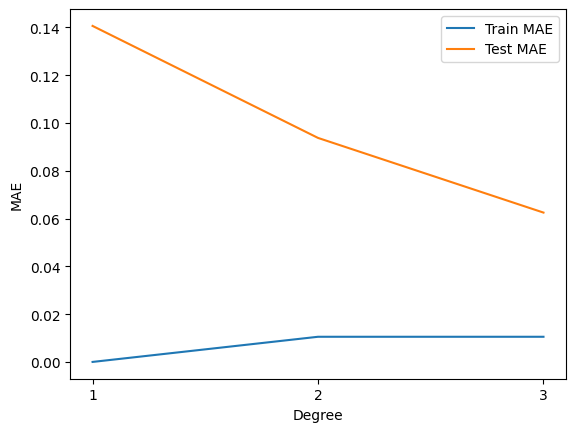

In [95]:
plot_errors(logistic_regression_errors)

#### Обучение модели-классификатора `SVC` с подбором гиперпараметров для разных ядер

In [96]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1]
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [1e-3, 1e-2, 1e-1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1],
        "svc__degree": [2, 3, 4],
        "svc__coef0": [0.0, 0.5, 1.0]
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

test_predict = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_predict)

print(f"Best params for SVC | {grid.best_params_}")
print(f"SVC | Test MAE = {test_mae:.4f}")

Best params for SVC | {'svc__C': 100, 'svc__kernel': 'linear'}
SVC | Test MAE = 0.1094


#### Выводы

В ходе работы были обучены модели-классификаторы `LogisticRegression` и `SVC`

Для `LogisticRegression` брутфорсом был выбран на основе метрики `MAE` лучший коэффициент регуляризации для каждой степени `PolynomialFeatures`; degrees = {1, 2, 3}

Для `SVC` при помощи `GridSearchCV` были подобраны у каждого ядра лучшие параметры

В итоге для `LogisticRegression` получаем такой результат = { degree = 3 | Test MAE = 0.0625 }, а для `SVC` = { Test MAE = 0.1094 }, `SVC` не превзошёл лучшую модель логистической регрессии. Для задачи классификации не совсем уместно использовать метрику `MAE` так как мы не видим полной картины результатов классификации классов, необходимо использовать метрики, например, $F_n$-мера